In [4]:
from wasabi.data_simulation import DataSimulation
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def _bin_counts_around_stim(
    peaks_ms: dict[int, np.ndarray],
    bin_ms: float,
    stim_times_ms: np.ndarray,
    art_before_ms: float,
    art_after_ms: float,
    win_ms: tuple[float, float],
):
    """
    Bin spike counts around each stimulation event.
    """
    window_start_ms, window_end_ms = float(win_ms[0]), float(win_ms[1])

    if peaks_ms is None or len(peaks_ms) == 0:
        return None, None, None, 0

    stim_times_ms = np.asarray(stim_times_ms, float).ravel()
    if stim_times_ms.size == 0:
        return None, None, None, 0

    # Left/right edges & centers
    left_window_edges_ms: list[float] = []
    edge_value = -art_before_ms
    while edge_value >= window_start_ms:
        left_window_edges_ms.append(edge_value)
        edge_value -= bin_ms
    left_window_edges_ms = np.array(left_window_edges_ms[::-1])

    right_window_edges_ms: list[float] = []
    edge_value = art_after_ms
    while edge_value <= window_end_ms:
        right_window_edges_ms.append(edge_value)
        edge_value += bin_ms
    right_window_edges_ms = np.array(right_window_edges_ms)

    # Bin centers on each side
    left_bin_centers_ms  = (
        left_window_edges_ms[:-1] + 0.5 * bin_ms
        if left_window_edges_ms.size > 1 else np.array([], float)
    )
    right_bin_centers_ms = (
        right_window_edges_ms[:-1] + 0.5 * bin_ms
        if right_window_edges_ms.size > 1 else np.array([], float)
    )

    bin_edges_ms   = np.concatenate([left_window_edges_ms, right_window_edges_ms])
    bin_centers_ms = np.concatenate([left_bin_centers_ms, right_bin_centers_ms])
    n_bins         = bin_centers_ms.size

    # Number of bins on the left side (used to offset right-side indices)
    n_left_bins = max(left_window_edges_ms.size - 1, 0)

    n_trials    = len(stim_times_ms)
    ch_keys = sorted(peaks_ms.keys())
    n_channels = len(ch_keys)

    # counts[trial_index, channel_index, bin_index]
    counts = np.zeros((n_trials, n_channels, n_bins), float)

    # Binning
    for trial_index, stim_time_ms in enumerate(stim_times_ms):
        trial_window_start_ms = stim_time_ms + window_start_ms
        trial_window_end_ms   = stim_time_ms + window_end_ms
        for ch_i, ch_id in enumerate(ch_keys):
            spike_times_ms = np.asarray(peaks_ms[ch_id], float).ravel()
            if spike_times_ms.size == 0:
                continue

            # Spikes within the overall peri-stim window (absolute)
            in_window_mask = (
                (spike_times_ms >= trial_window_start_ms) &
                (spike_times_ms <= trial_window_end_ms)
            )
            if not in_window_mask.any():
                continue

            # Relative spike times in ms, centered at the stim
            spike_times_rel_ms = spike_times_ms[in_window_mask] - stim_time_ms

            # Exclude spikes in the artifact gap [-art_before_ms, +art_after_ms]
            left_side_mask  = (
                (spike_times_rel_ms >= window_start_ms) &
                (spike_times_rel_ms < -art_before_ms)
            )
            right_side_mask = (
                (spike_times_rel_ms > art_after_ms) &
                (spike_times_rel_ms <= window_end_ms)
            )

            # ---- LEFT side binning ----
            if left_window_edges_ms.size > 1 and left_side_mask.any():
                spike_times_left_ms = spike_times_rel_ms[left_side_mask]
                # Find bin index j such that edges[j] <= t < edges[j+1]
                left_bin_indices = np.searchsorted(
                    left_window_edges_ms, spike_times_left_ms, side="right"
                ) - 1
                valid_left_bins = (
                    (left_bin_indices >= 0) &
                    (left_bin_indices < left_window_edges_ms.size - 1)
                )
                if valid_left_bins.any():
                    np.add.at(counts[trial_index, ch_i], left_bin_indices[valid_left_bins], 1.0)

            # ---- RIGHT side binning ----
            if right_window_edges_ms.size > 1 and right_side_mask.any():
                spike_times_right_ms = spike_times_rel_ms[right_side_mask]
                right_bin_indices_local = np.searchsorted(
                    right_window_edges_ms, spike_times_right_ms, side="right"
                ) - 1
                valid_right_bins = (
                    (right_bin_indices_local >= 0) &
                    (right_bin_indices_local < right_window_edges_ms.size - 1)
                )
                if valid_right_bins.any():
                    # Map right-side bins into global bin indices
                    right_bin_indices_global = (
                        right_bin_indices_local[valid_right_bins] + n_left_bins
                    )
                    np.add.at(counts[trial_index, ch_i], right_bin_indices_global, 1.0)
    return counts, bin_centers_ms, bin_edges_ms, n_left_bins

def _smooth_segment(seg_counts, seg_edges, seg_centers, sigma_ms):
        """
        """
        L = seg_centers.size
        if L == 0 or sigma_ms <= 0:
            return seg_counts.copy()

        # bin widths
        dt_ms = np.diff(seg_edges)
        dt_sec = np.clip(dt_ms / 1000.0, 1e-12, None)

        # convert counts → rates
        rates = seg_counts / dt_sec[None, None, :]   # broadcast dt

        # Gaussian weights
        diff = seg_centers[:, None] - seg_centers[None, :]
        W = np.exp(-(diff**2) / (2.0 * sigma_ms**2))   # (L, L)

        # output
        out = np.full_like(rates, np.nan)

        for tr in range(rates.shape[0]):
            for ch in range(rates.shape[1]):
                r = rates[tr, ch]
                valid = np.isfinite(r)
                if not valid.any():
                    continue

                r_valid = np.where(valid, r, 0.0)
                num = r_valid @ W.T
                den = (valid.astype(float) @ W.T).clip(1e-12, None)
                out[tr, ch] = num / den

        return out

def _smooth_counts_gauss(
    counts: np.ndarray,
    edges: np.ndarray,
    bin_centers_ms: np.ndarray,
    sigma_ms: float,
    left_bins: int,
) -> np.ndarray:
    """
    Smooth spike counts -> firing rates (Hz) separately on left and right sides
    of the stim-blank gap, using a Gaussian in ms (NaN-aware at the per-bin level).
    """
    if counts is None or np.size(counts) == 0:
        return np.asarray(counts, float)

    gap_bin = int(left_bins)
    gap_bin = max(0, min(gap_bin, counts.shape[-1]))  # clamp

    left_counts   = counts[:, :, :gap_bin]
    right_counts  = counts[:, :, gap_bin:]
    left_centers  = bin_centers_ms[:gap_bin]
    right_centers = bin_centers_ms[gap_bin:]

    # edges is length (T+2): left edges (L+1) + right edges (R+1)
    left_edges  = edges[:gap_bin + 1]
    right_edges = edges[gap_bin + 1:]

    left_sm  = _smooth_segment(left_counts,  left_edges,  left_centers,  sigma_ms)
    right_sm = _smooth_segment(right_counts, right_edges, right_centers, sigma_ms)

    out = np.full_like(counts, np.nan, dtype=float)
    out[:, :, :gap_bin] = left_sm
    out[:, :, gap_bin:] = right_sm
    return out


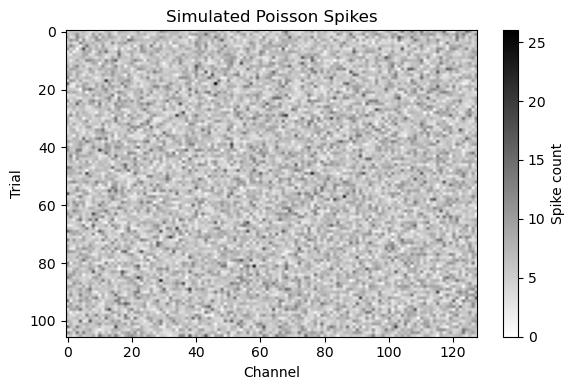

In [ ]:
n_trials = 20

n_ch = 128
n_stim = 10
base_rate = 5.0

# # seed
# np.random.seed(100)
# random.seed(100)

sim = DataSimulation(n_trials, n_ch, n_stim, base_rate)
rates = sim.base_rate * np.ones((n_trials, n_ch))
stim_trials = sim.generate_stim_trials()
rates = sim.add_stim_perturbation(rates + 5.0 * stim_trials)
spikes = sim.poisson_spikes(rates)


nprw_counts, nprw_rel_t, nprw_edges_ms, nprw_left_bins = _bin_counts_around_stim(
    nprw_peak_ms_dedup, NPRW_BIN_MS, stim_ms_nprw_all,
    NPRW_MS_BEFORE, (STIM_DUR + NPRW_TAIL_MS), WIN_MS
)

ua_rate_hz = _smooth_counts_gauss(ua_counts, ua_edges_ms, ua_rel_t, UA_SIGMA_MS, ua_left_bins)
nprw_rates_hz = _smooth_counts_gauss(nprw_counts, nprw_edges_ms, nprw_rel_t, NPRW_SIGMA_MS, nprw_left_bins)

ua_rate_hz_baselined = rcp.baseline_zero_each_trial(ua_rate_hz, ua_rel_t, normalize_first_ms=NORMALIZE_FIRST_MS)
nprw_rates_hz_baselined = rcp.baseline_zero_each_trial(nprw_rates_hz, nprw_rel_t, normalize_first_ms=NORMALIZE_FIRST_MS)


# plot
plt.figure(figsize=(6, 4))
plt.imshow(spikes, aspect="auto", cmap="gray_r")
plt.xlabel("Channel")
plt.ylabel("Trial")
plt.title("Simulated Poisson Spikes")
plt.colorbar(label="Spike count")
plt.tight_layout()
plt.show()


# plt.figure(figsize=(25, 15))
# for ch_select in range(10):
#     ax = plt.subplot(4, 3, ch_select+1)
#     plt.plot(NPRW_rel_t, np.nanmean(pcs_all[:, ch_select, :], axis = 0).T,color="red")
#     plt.plot(NPRW_rel_t, pcs_all[:, ch_select, :].T,color="gray",linewidth=0.5,alpha=0.5)
#     plt.title("PC" + str(ch_select + 1))
#     ax.axvspan(-20, 120, alpha=0.2)
    
# plt.suptitle("NPRW PCs over time\n")
# plt.tight_layout()

In [6]:
rates

array([[ 5.94313087,  5.94313087,  5.94313087, ..., 10.94313087,
         5.94313087,  5.94313087],
       [ 5.94313087,  5.94313087,  5.94313087, ...,  5.94313087,
         5.94313087, 10.94313087],
       [ 5.94313087,  5.94313087,  5.94313087, ...,  5.94313087,
         5.94313087,  5.94313087],
       ...,
       [ 5.94313087,  5.94313087, 10.94313087, ...,  5.94313087,
         5.94313087,  5.94313087],
       [10.94313087,  5.94313087,  5.94313087, ...,  5.94313087,
         5.94313087,  5.94313087],
       [ 5.94313087,  5.94313087,  5.94313087, ...,  5.94313087,
         5.94313087,  5.94313087]], shape=(106, 128))